## 1. Setup

In [1]:
!pip install -q -U transformers datasets optuna evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 89.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.2 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatibl

In [2]:
import numpy as np
import pandas as pd
import re
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Torch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


## 2. Load & Clean Data

Loading from the original upstream source directly, applying only the light-cleaning steps (no stopword removal, no lemmatization).

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
print("Initial shape:", df.shape)

Initial shape: (37249, 2)


In [4]:
# Drop nulls
df.dropna(inplace=True)

# Drop full-row duplicates
df.drop_duplicates(inplace=True)

# Drop text-only duplicates (comments that repeat even if other metadata differs)
df.drop_duplicates(subset='clean_comment', inplace=True)

print("Shape after dropna + dedup:", df.shape)

Shape after dropna + dedup: (36799, 2)


In [5]:
# Replace newlines with spaces
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)

# Remove non-English characters, keep basic punctuation that carries sentiment signal
df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

# Normalize whitespace
def normalize_whitespaces(text):
    pattern = re.compile(r"\s+")
    return re.sub(pattern, " ", text).strip()

df['clean_comment'] = df['clean_comment'].apply(normalize_whitespaces)

# Drop rows that became empty after cleaning
df = df[~(df['clean_comment'] == "")]

# Explicit lowercase (paired with distilbert-base-uncased)
df['clean_comment'] = df['clean_comment'].str.lower()

print("Final shape:", df.shape)

Final shape: (36706, 2)


In [6]:
# Sanity checks
print("Duplicate comments remaining:", df['clean_comment'].duplicated().sum())
print()
print(df['category'].value_counts())
print()
print(df['category'].value_counts(normalize=True).mul(100).round(2))
print()
for i in range(3):
    print(repr(df['clean_comment'].iloc[i]))
    print()

Duplicate comments remaining: 213

category
 1    15771
 0    12685
-1     8250
Name: count, dtype: int64

category
 1    42.97
 0    34.56
-1    22.48
Name: proportion, dtype: float64

'family mormon have never tried explain them they still stare puzzled from time time like some kind strange creature nonetheless they have come admire for the patience calmness equanimity acceptance and compassion have developed all the things buddhism teaches'

'buddhism has very much lot compatible with christianity especially considering that sin and suffering are almost the same thing suffering caused wanting things shouldn want going about getting things the wrong way christian this would mean wanting things that don coincide with god will and wanting things that coincide but without the aid jesus buddhism could also seen proof god all mighty will and omnipotence certainly christians are lucky have one such christ there side but what about everyone else well many christians believe god grace salvat

In [7]:
df.to_csv('cleaned_data_light.csv', index=False)

## 3. Label Encoding & Train/Val/Test Split

In [8]:
label_map = {-1: 0, 0: 1, 1: 2}  # negative, neutral, positive
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
label2id = {v: k for k, v in id2label.items()}

df['label'] = df['category'].map(label_map)

texts = df['clean_comment'].tolist()
labels = df['label'].tolist()

# 70/15/15 split, stratified to preserve class balance across all splits
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.30, stratify=labels, random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print("Train:", len(train_texts), "Val:", len(val_texts), "Test:", len(test_texts))

Train: 25694 Val: 5506 Test: 5506


## 4. Tokenization

Using the `datasets` library's `Dataset` object, which `Trainer` consumes natively — this also gives us easy on-the-fly tokenization via `.map()`.

In [9]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Check token length distribution to pick a sensible max_length
sample_lengths = [len(tokenizer.encode(t)) for t in train_texts[:2000]]
print("Token length — mean:", np.mean(sample_lengths), "95th pct:", np.percentile(sample_lengths, 95), "max:", np.max(sample_lengths))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (621 > 512). Running this sequence through the model will result in indexing errors


Token length — mean: 36.1105 95th pct: 118.04999999999995 max: 1123


In [10]:
MAX_LENGTH = 128

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
val_dataset = Dataset.from_dict({'text': val_texts, 'label': val_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
val_dataset = val_dataset.map(tokenize_fn, batched=True)
test_dataset = test_dataset.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/25694 [00:00<?, ? examples/s]

Map:   0%|          | 0/5506 [00:00<?, ? examples/s]

Map:   0%|          | 0/5506 [00:00<?, ? examples/s]

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    macro_f1 = f1_score(labels, preds, average='macro')
    accuracy = (preds == labels).mean()
    return {'accuracy': accuracy, 'macro_f1': macro_f1}

## 5. Baseline Fine-Tuning Run

A single untuned run first, to confirm the pipeline works end-to-end and to get a reference point before the Optuna search.

In [12]:
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
).to(device)

baseline_args = TrainingArguments(
    output_dir='./baseline_results',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    report_to='none',
)

baseline_trainer = Trainer(
    model=baseline_model,
    args=baseline_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

baseline_trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super(

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.678816,0.645355,0.889757,0.876665
2,0.401200,0.529027,0.916092,0.908065
3,0.286239,0.506715,0.922448,0.915073


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=2409, training_loss=0.5905374324682987, metrics={'train_runtime': 577.7756, 'train_samples_per_second': 133.412, 'train_steps_per_second': 4.169, 'total_flos': 2426258187395136.0, 'train_loss': 0.5905374324682987, 'epoch': 3.0})

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

    negative       0.90      0.85      0.87      1238
     neutral       0.96      0.96      0.96      1903
    positive       0.92      0.95      0.93      2365

    accuracy                           0.93      5506
   macro avg       0.93      0.92      0.92      5506
weighted avg       0.93      0.93      0.93      5506



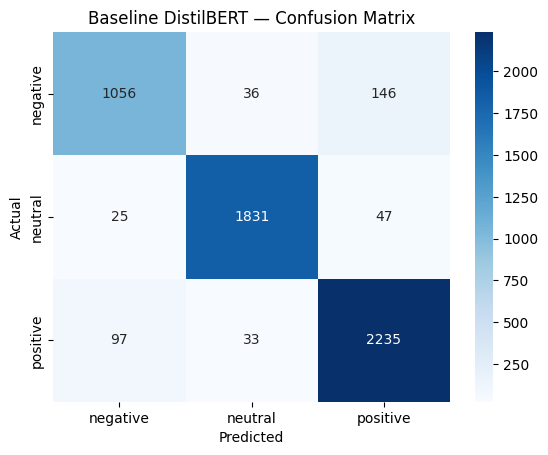

In [13]:
baseline_test_results = baseline_trainer.predict(test_dataset)
baseline_preds = np.argmax(baseline_test_results.predictions, axis=1)

print(classification_report(test_labels, baseline_preds, target_names=['negative', 'neutral', 'positive']))

cm = confusion_matrix(test_labels, baseline_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline DistilBERT — Confusion Matrix')
plt.show()

## 6. Optuna Hyperparameter Search

Searching over learning rate, batch size, number of epochs, and warmup ratio. Each trial fine-tunes fresh from the pretrained checkpoint (no leakage between trials) and is scored on **validation macro-F1** — macro-F1 rather than accuracy because of the class imbalance (22% negative vs 43% positive), same reasoning you applied with the Telco churn project's threshold analysis.

In [14]:
def objective(trial):
    lr = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32])
    epochs = trial.suggest_int('epochs', 2, 4)
    warmup_ratio = trial.suggest_float('warmup_ratio', 0.0, 0.1)
    weight_decay = trial.suggest_float('weight_decay', 0.0, 0.1)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
    ).to(device)

    args = TrainingArguments(
        output_dir=f'./optuna_trial_{trial.number}',
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        warmup_ratio=warmup_ratio,
        weight_decay=weight_decay,
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=200,
        report_to='none',
        disable_tqdm=True,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_result = trainer.evaluate()

    # free GPU memory between trials
    del model, trainer
    torch.cuda.empty_cache()

    return eval_result['eval_macro_f1']

In [15]:
study = optuna.create_study(direction='maximize', study_name='distilbert_reddit_sentiment')
study.optimize(objective, n_trials=15)

print("Best macro-F1:", study.best_value)
print("Best params:", study.best_params)

[I 2026-06-24 06:57:21,308] A new study created in memory with name: distilbert_reddit_sentiment


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension

{'loss': '1.337', 'grad_norm': '6.518', 'learning_rate': '3.697e-05', 'epoch': '0.4975'}
{'loss': '0.652', 'grad_norm': '8.366', 'learning_rate': '2.963e-05', 'epoch': '0.995'}
{'eval_loss': '0.574', 'eval_accuracy': '0.9025', 'eval_macro_f1': '0.8897', 'eval_runtime': '11.72', 'eval_samples_per_second': '469.7', 'eval_steps_per_second': '7.422', 'epoch': '1'}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

{'loss': '0.2251', 'grad_norm': '11.16', 'learning_rate': '1.851e-05', 'epoch': '2.242'}
{'loss': '0.2359', 'grad_norm': '17.48', 'learning_rate': '1.589e-05', 'epoch': '2.491'}
{'loss': '0.2107', 'grad_norm': '28.17', 'learning_rate': '1.327e-05', 'epoch': '2.74'}
{'loss': '0.1945', 'grad_norm': '13.86', 'learning_rate': '1.065e-05', 'epoch': '2.989'}
{'eval_loss': '0.5472', 'eval_accuracy': '0.9402', 'eval_macro_f1': '0.9344', 'eval_runtime': '13.2', 'eval_samples_per_second': '417.2', 'eval_steps_per_second': '13.11', 'epoch': '3'}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '0.153', 'grad_norm': '0.1761', 'learning_rate': '8.028e-06', 'epoch': '3.238'}
{'loss': '0.141', 'grad_norm': '1.237', 'learning_rate': '5.409e-06', 'epoch': '3.487'}
{'loss': '0.1273', 'grad_norm': '30.33', 'learning_rate': '2.79e-06', 'epoch': '3.736'}
{'loss': '0.1293', 'grad_norm': '20.66', 'learning_rate': '1.703e-07', 'epoch': '3.985'}
{'eval_loss': '0.5776', 'eval_accuracy': '0.9401', 'eval_macro_f1': '0.9345', 'eval_runtime': '13.22', 'eval_samples_per_second': '416.4', 'eval_steps_per_second': '13.08', 'epoch': '4'}
{'train_runtime': '778.4', 'train_samples_per_second': '132', 'train_steps_per_second': '4.127', 'train_loss': '0.4308', 'epoch': '4'}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
[I 2026-06-24 09:26:26,294] Trial 14 finished with value: 0.9344619808903593 and parameters: {'learning_rate': 3.893601103986293e-05, 'batch_size': 16, 'epochs': 4, 'warmup_ratio': 0.07424851346708233, 'weight_decay': 0.01751451533379777}. Best is trial 8 with value: 0.9355832085151615.


{'eval_loss': '0.5776', 'eval_accuracy': '0.9401', 'eval_macro_f1': '0.9345', 'eval_runtime': '13.27', 'eval_samples_per_second': '414.9', 'eval_steps_per_second': '13.04', 'epoch': '4'}
Best macro-F1: 0.9355832085151615
Best params: {'learning_rate': 4.4293695039094384e-05, 'batch_size': 32, 'epochs': 4, 'warmup_ratio': 0.039711640755669624, 'weight_decay': 0.02584975139953466}


/tmp/ipykernel_58/3572419173.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


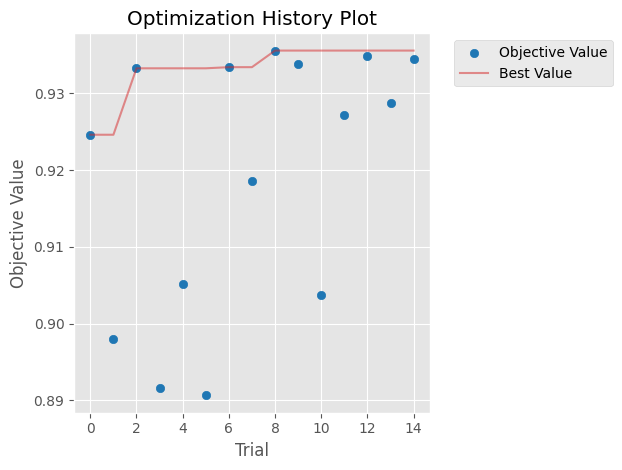

/tmp/ipykernel_58/3572419173.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


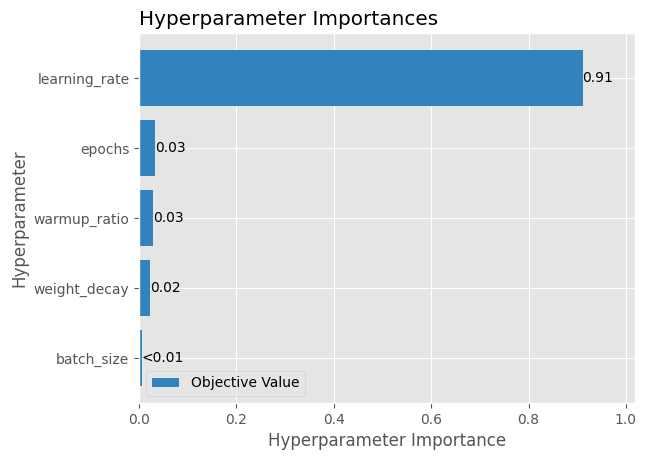

In [16]:
# Optuna's built-in visualizations
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

## 7. Final Model — Trained with Best Hyperparameters

Retrain from scratch (fresh pretrained checkpoint) using the best trial's hyperparameters, then evaluate once on the held-out test set.

In [17]:
best_params = study.best_params
print(best_params)

{'learning_rate': 4.4293695039094384e-05, 'batch_size': 32, 'epochs': 4, 'warmup_ratio': 0.039711640755669624, 'weight_decay': 0.02584975139953466}


In [18]:
final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
).to(device)

final_args = TrainingArguments(
    output_dir='./final_results',
    learning_rate=best_params['learning_rate'],
    per_device_train_batch_size=best_params['batch_size'],
    per_device_eval_batch_size=best_params['batch_size'],
    num_train_epochs=best_params['epochs'],
    warmup_ratio=best_params['warmup_ratio'],
    weight_decay=best_params['weight_decay'],
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=50,
    report_to='none',
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

final_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.576345,0.563349,0.907374,0.894944
2,0.325122,0.433423,0.928623,0.921336
3,0.171519,0.432020,0.938794,0.933173
4,0.161259,0.473760,0.938612,0.933143


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1608, training_loss=0.4290877431631088, metrics={'train_runtime': 682.7235, 'train_samples_per_second': 150.538, 'train_steps_per_second': 2.355, 'total_flos': 3381561281719692.0, 'train_loss': 0.4290877431631088, 'epoch': 4.0})

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final tuned model — test metrics: {'test_loss': 0.4139785170555115, 'test_accuracy': 0.9416999636759898, 'test_macro_f1': 0.9356727747138707, 'test_runtime': 11.8626, 'test_samples_per_second': 464.147, 'test_steps_per_second': 7.334}

              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      1238
     neutral       0.98      0.97      0.97      1903
    positive       0.94      0.95      0.94      2365

    accuracy                           0.94      5506
   macro avg       0.94      0.93      0.94      5506
weighted avg       0.94      0.94      0.94      5506



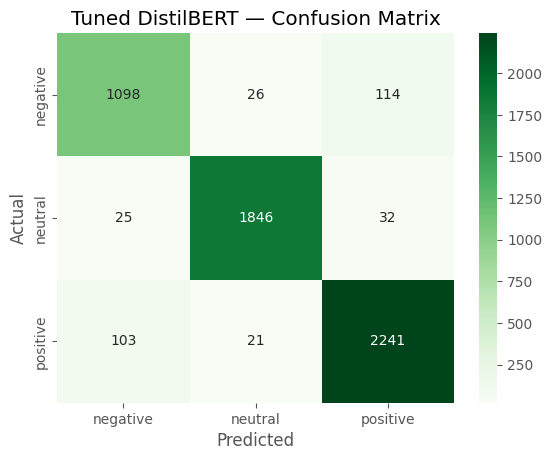

In [19]:
final_test_results = final_trainer.predict(test_dataset)
final_preds = np.argmax(final_test_results.predictions, axis=1)
final_metrics = final_test_results.metrics

print("Final tuned model — test metrics:", final_metrics)
print()
print(classification_report(test_labels, final_preds, target_names=['negative', 'neutral', 'positive']))

cm_final = confusion_matrix(test_labels, final_preds)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned DistilBERT — Confusion Matrix')
plt.show()

## 8. Save Model

In [20]:
final_trainer.save_model('./distilbert_reddit_sentiment_tuned')
tokenizer.save_pretrained('./distilbert_reddit_sentiment_tuned')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./distilbert_reddit_sentiment_tuned/tokenizer_config.json',
 './distilbert_reddit_sentiment_tuned/tokenizer.json')

1. Fine-tuned DistilBERT outperformed every classical/deep-learning baseline by a wide margin — roughly a 9-10 point accuracy improvement over the best prior model (BiLSTM at ~84.4%), even while working from a stopword-stripped input that's suboptimal for transformers.
2. Tuning improved overall macro-F1 from 0.92 → 0.93, but the more meaningful change was concentrated on the negative class — recall rose from 0.85 → 0.89, and total negative misclassifications dropped from 182 to 140 out of 1238 samples. This is the class that struggled across every model in this project (SVM, ANN, BiLSTM), so this is the most important number to highlight.
3. Higher learning rates (3e-05 to 5e-05 range) and more epochs (4) consistently produced the best trials; low learning rates (under 2e-05) underperformed even with more epochs to compensate. Batch size and weight decay had a smaller, less consistent effect. Reference the plot_param_importances chart for the precise ranking.
4. The dominant confusion is still negative↔positive (217 combined cross-errors) rather than negative↔neutral — consistent with the baseline. This suggests some comments carry genuinely ambiguous or sarcastic sentiment that's hard to resolve even for a tuned transformer, possibly compounded by the missing stopwords/negation cues in the source text.
5. The clean_comment field was already stopword-stripped by the original dataset's author before this project began (verified against the upstream source) — a constraint that likely capped how much further transformer performance could improve. A version of this project on naturally-structured text would be a reasonable future extension to mention.
6. Across the series — TF-IDF+SVM → ANN/BiLSTM → fine-tuned DistilBERT — increasingly sophisticated approaches showed increasingly large returns on this dataset, with the biggest single jump coming from pretrained transformer representations, even working against a data limitation that should have worked against them.